
# Energy Systems Modelling — Capacity Expansion Model

This notebook implements a linear, cost-minimising capacity expansion model with hourly resolution for the Danish electricity system in 2030. The model is parameterised on 2024 data and compares two flexibility scenarios.

- **Part 0**: Data loading
- **Part 1**: Flexibility envelopes (IV-estimated industrial elasticities)
- **Part 2**: Scenario modelling
  - Scenario 1: BESS storage, no Demand-Side-Flexibility (baseline)
  - Scenario 2: BESS storage + industrial Demand-Side-Flexibility
    - v1: Sectors whose estimated elasticity is significant at the 1% level
    - v2: Sectors whose estimated elasticity is significant at the 5% level
    - v3: All Sectors

**Key assumptions :**
- Base year: 2024. All prices, CAPEX and capacity factors fixed at 2024 values.
- Demand multiplier: 1.55 × 2024 consumption — based on DEA 2030 projections
- Copper-plate: no intra-Danish congestion
- Imports capped at 5% of annual demand
- Capacity limits: 45 GW PV, 12 GW onshore wind, 35 GW offshore. 
- Installed BESS: 3,296 MW / 6,450 MWh (~2-hour duration), η = 0.95 round-trip — Energistyrelsen AF25 (2025b)
- All electricity from non-dispatchable sources and imports
- Perfect foresight 



---
# Part 0: Data Loading

In [1]:
# --- Defining data paths and loading packages ---

using CSV, DataFrames, Dates, Glob, Parquet2, Statistics

# All  model inputs 
# Project root = one level above this notebook (ESM/)
project_root = abspath(joinpath(pwd(), ".."))
data_path = joinpath(project_root, "data", "Data_for_modelling")

# hourly consumption parquet files 
consumption_path = joinpath(project_root, "data", "DK_consumption_2025")

# industry consumption parquet files 
Industry_path = joinpath(project_root, "data", "raw", "consumption_industry_hourly_monthly")


println("data_path    : ", data_path)
println("consumption_path: ", consumption_path)
println("Industry_path: ", Industry_path)

data_path    : <project>/data/Data_for_modelling
consumption_path: <project>/data/DK_consumption_2025
Industry_path: <project>/data/Data/Consumption_industry_hourly_monthly


In [2]:
# ── Capacity factors ───────────────────────────────────────────────────────
df_pv   = CSV.read(joinpath(data_path, "ninja_pv_2024.csv"),   DataFrame)
df_wind = CSV.read(joinpath(data_path, "ninja_wind_2024.csv"), DataFrame)


# ── Import prices (EUR/MWh, 2024, leap day removed) ───────────────────────
price_col = Symbol("Price (EUR/MWhe)")
df_NO = CSV.read(joinpath(data_path, "Norway.csv"),      DataFrame)
df_DE = CSV.read(joinpath(data_path, "Germany.csv"),     DataFrame)
df_SE = CSV.read(joinpath(data_path, "Sweden.csv"),      DataFrame)
df_UK = CSV.read(joinpath(data_path, "UK.csv"),          DataFrame)
df_NE = CSV.read(joinpath(data_path, "Netherlands.csv"), DataFrame)

C = ["NO", "DE", "SE", "UK", "NE"]

# ── Transmission capacity limits (MW) — Energinet (2018) ─────
trans_cap = Dict(
    "NO" => 1_700.0,
    "SE" => 2_380.0,
    "DE" => 4_500.0,
    "UK" => 1_400.0,
    "NE" => 700.0
)


println("✓ Main datasets loaded.")
println("  df_wind : ", nrow(df_wind), " hours")
println("  df_pv   : ", nrow(df_pv),   " hours")

✓ Main datasets loaded.
  df_wind : 8760 hours
  df_pv   : 8760 hours


In [3]:
# ── Denmark hourly consumption  ────────────────────────────
consumption_files = filter(f -> endswith(f, ".parquet"), readdir(consumption_path, join=true))

consumption = reduce(vcat, [DataFrame(Parquet2.Dataset(f)) for f in consumption_files])

println("Loaded ", length(consumption_files), " files → ", nrow(consumption), " rows")

Loaded 12 files → 131400 rows


In [4]:
# ── Industry hourly consumption (DK36 sectors) — 2022 ────────────────────
using DataFrames, Parquet2, Glob


industry = vcat([
    DataFrame(Parquet2.Dataset(joinpath(Industry_path, f)))
    for f in [
        "consumption_industry_hour_2022_01.parquet",
        "consumption_industry_hour_2022_02.parquet",
        "consumption_industry_hour_2022_03.parquet",
        "consumption_industry_hour_2022_04.parquet",
        "consumption_industry_hour_2022_05.parquet",
        "consumption_industry_hour_2022_06.parquet",
        "consumption_industry_hour_2022_07.parquet",
        "consumption_industry_hour_2022_08.parquet",
        "consumption_industry_hour_2022_09.parquet",
        "consumption_industry_hour_2022_10.parquet",
        "consumption_industry_hour_2022_11.parquet",
        "consumption_industry_hour_2022_12.parquet"
    ]
]...)

# ── DK36 → English rename dictionary (estimation sample only) ────────────
dk36_rename = Dict(
    "Landbrug, skovbrug og fiskeri"                                 => "Agriculture, forestry and fishing",
    "Føde-, drikke- og tobaksvareindustri"                          => "Food, beverages and tobacco",
    "Træ- og papirindustri, trykkerier"                             => "Wood, paper and printing",
    "Kemiskindustri, Olieraffinaderier og Medicinalindustri"        => "Chemicals, oil refining and pharmaceuticals",
    "Plast-, glas- og betonindustri"                                => "Plastics, glass and concrete",
    "Metalindustri"                                                 => "Metal manufacturing",
    "Elektronikindustri"                                            => "Electronics manufacturing",
    "Fremst. af elektrisk udstyr"                                   => "Electrical equipment manufacturing",
    "Maskinindustri"                                                => "Machinery manufacturing",
    "Transportmiddelindustri"                                       => "Transport equipment manufacturing",
    "Tekstil - og læderindustri & Møbel og anden industri mv."     => "Textiles, leather and furniture",
    "Bygge og anlæg"                                                => "Construction",
    "Handel"                                                        => "Trade",
    "Transport"                                                     => "Transport",
    "Hoteller og restauranter"                                      => "Hotels and restaurants",
    "Forlag, tv og radio"                                           => "Publishing, TV and radio",
    "Telekommunikation &It - og informationstjenester"              => "Telecommunications and IT services",
    "Finansiering og forsikring"                                    => "Finance and insurance",
    "Ejendomshandel og udlejning"                                   => "Real estate",
    "Rådgivning mv."                                                => "Consulting services",
    "Forskning og udvikling"                                        => "Research and development",
    "Reklame og øvrig erhvervsservice"                              => "Advertising and business services",
    "Rejsebureauer, rengøring og anden operationel service"         => "Travel agencies and operational services",
    "Offentlig administration, forsvar og politi"                   => "Public administration and defence",
    "Undervisning"                                                  => "Education",
    "Sundhedsvæsen"                                                 => "Healthcare",
    "Sociale institutioner"                                         => "Social institutions",
    "Kultur og fritid"                                              => "Culture and recreation",
    "Andre serviceydelser  mv."                                     => "Other services"
)

# Apply rename and drop excluded sectors
industry[!, :sector] = map(x -> get(dk36_rename, coalesce(x, ""), missing), industry.DK36Title)
industry = filter(row -> !ismissing(row.sector), industry)

println("Unique sectors retained: ", length(unique(industry.sector)))
println(sort(unique(industry.sector)))

println("Rows loaded: ", nrow(industry))
println("Columns    : ", names(industry))
println(first(industry, 3))

Unique sectors retained: 29
Union{Missing, String}["Advertising and business services", "Agriculture, forestry and fishing", "Chemicals, oil refining and pharmaceuticals", "Construction", "Consulting services", "Culture and recreation", "Education", "Electrical equipment manufacturing", "Electronics manufacturing", "Finance and insurance", "Food, beverages and tobacco", "Healthcare", "Hotels and restaurants", "Machinery manufacturing", "Metal manufacturing", "Other services", "Plastics, glass and concrete", "Public administration and defence", "Publishing, TV and radio", "Real estate", "Research and development", "Social institutions", "Telecommunications and IT services", "Textiles, leather and furniture", "Trade", "Transport", "Transport equipment manufacturing", "Travel agencies and operational services", "Wood, paper and printing"]
Rows loaded: 254040
Columns    : ["TimeUTC", "TimeDK", "DK36Code", "DK36Title", "DK19Code", "DK19Title", "Consumption_MWh", "sector"]
3×8 DataFrame
 Row

In [5]:
# Sum across regions, keep category breakdown
consumption_agg = combine(
    groupby(consumption, [:TimeDK, :ConsumerCategory3]),
    :ConsumptionkWh => sum => :ConsumptionkWh
)

# Pivot categories to columns
consumption_wide = unstack(consumption_agg, :TimeDK, :ConsumerCategory3, :ConsumptionkWh)

rename!(consumption_wide, Dict(
    "Privat"                   => "Privat_kWh",
    "Erhverv"                  => "Erhverv_kWh",
    "Offentlige foretagender"  => "Offentlig_kWh"
))



# Build day index from TimeDK column directly
consumption_wide[!, :Date] = Date.(DateTime.(consumption_wide.TimeDK, "yyyy-mm-ddTHH:MM:SS"))




consumption_wide.Total_kWh = consumption_wide.Privat_kWh .+
                              consumption_wide.Erhverv_kWh .+
                              consumption_wide.Offentlig_kWh

sort!(consumption_wide, :TimeDK)
first(consumption_wide, 5)


Row,TimeDK,Erhverv_kWh,Offentlig_kWh,Privat_kWh,Date,Total_kWh
,String?,Float64?,Float64?,Float64?,Date,Float64
1,2025-01-01T00:00:00,2.76009e6,2.25686e5,1.27642e6,2025-01-01,4.26219e6
2,2025-01-01T01:00:00,2.69977e6,2.21497e5,1.29427e6,2025-01-01,4.21554e6
3,2025-01-01T02:00:00,2.72109e6,2.18418e5,1.24438e6,2025-01-01,4.18389e6
4,2025-01-01T03:00:00,2.78639e6,2.16757e5,1.1616e6,2025-01-01,4.16475e6
5,2025-01-01T04:00:00,2.75336e6,2.18034e5,1.05043e6,2025-01-01,4.02182e6


In [6]:
#Scale to 2030 levels

consumption_wide.Privat_kWh    .*= 1.55
consumption_wide.Erhverv_kWh   .*= 1.55
consumption_wide.Offentlig_kWh .*= 1.55
consumption_wide.Total_kWh     .*= 1.55

println("✓ Consumption data processed and scaled to 2030 levels.")

✓ Consumption data processed and scaled to 2030 levels.


In [7]:
# ── Regional RES capacity (MW) by NUTS2 — Energinet ───────────────────────
df_regions = DataFrame(
    NUTS2           = ["DK01", "DK02",  "DK03",  "DK04",  "DK05" ],
    OffshoreWind_MW = [50.8,   994.0,   778.0,   815.0,   7.6   ],
    OnshoreWind_MW  = [65.7,   680.0,   981.0,   1900.0,  1232.0],
    Solar_MW        = [274.0,  967.0,   1627.0,  1525.0,  433.0 ],
)
df_regions.TotalWind_MW = df_regions.OffshoreWind_MW .+ df_regions.OnshoreWind_MW

# Sets
H       = 1:nrow(consumption_wide)
P       = ["onshore", "offshore", "pv"]
regions = df_regions.NUTS2

# Regional deployment shares
total_onshore  = sum(df_regions.OnshoreWind_MW)
total_offshore = sum(df_regions.OffshoreWind_MW)

alpha_onshore  = Dict(("onshore",  row.NUTS2) => row.OnshoreWind_MW  / total_onshore  for row in eachrow(df_regions))
alpha_offshore = Dict(("offshore", row.NUTS2) => row.OffshoreWind_MW / total_offshore for row in eachrow(df_regions))
alpha_pv       = Dict(("pv", "NAT") => 1.0)
alpha          = merge(alpha_onshore, alpha_offshore, alpha_pv)

# Regional wind CFs → aggregated national tech-level CFs
cf_wind_region = Dict((reg, h) => df_wind[!, Symbol(reg)][h] for reg in regions, h in H)
cf_onshore     = Dict(("onshore",  h) => sum(alpha[("onshore",  reg)] * cf_wind_region[(reg, h)] for reg in regions) for h in H)
cf_offshore    = Dict(("offshore", h) => sum(alpha[("offshore", reg)] * cf_wind_region[(reg, h)] for reg in regions) for h in H)
cf_pv          = Dict(("pv",       h) => df_pv.NATIONAL[h] for h in H)
cf             = merge(cf_onshore, cf_offshore, cf_pv)

println("✓ Capacity factors computed.") 

✓ Capacity factors computed.


In [8]:
# ── Disaggregated hourly demand (kWh → MWh) ───────────────────────────────
demand_ind_dict = Dict(h => consumption_wide.Erhverv_kWh[h]   / 1000.0 for h in H)
demand_pub_dict = Dict(h => consumption_wide.Offentlig_kWh[h] / 1000.0 for h in H)
demand_hh_dict  = Dict(h => consumption_wide.Privat_kWh[h]    / 1000.0 for h in H)

println("  Industrial : ", round(sum(values(demand_ind_dict)) / 1e6, digits=2), " TWh")
println("  Public     : ", round(sum(values(demand_pub_dict)) / 1e6, digits=2), " TWh")
println("  Household  : ", round(sum(values(demand_hh_dict))  / 1e6, digits=2), " TWh")
println("  Total      : ", round((sum(values(demand_ind_dict)) + 
                                  sum(values(demand_pub_dict)) + 
                                  sum(values(demand_hh_dict))) / 1e6, digits=2), " TWh")

  Industrial : 37.39 TWh
  Public     : 3.73 TWh
  Household  : 15.32 TWh
  Total      : 56.43 TWh


### Defining regional distribution

We assume each technology $p \in P$ has a fixed regional distribution, and that new capacity scales proportionally:

$$
K_{p,r}
= \alpha_{p,r}\,\big(K_p^{0} + K_p^{\text{new}}\big).
$$

For wind technologies, regional capacity factors are aggregated into a single technology-level factor:

$$
\mathrm{CF}_{p,h}
= \sum_{r} \alpha_{p,r}\,\mathrm{CF}^{\mathrm{wind}}_{r,h},
\qquad p \in \{\text{onshore},\,\text{offshore}\}.
$$

For PV (national only):

$$
\mathrm{CF}_{\text{pv},h}
= \mathrm{CF}^{\mathrm{pv}}_{\text{NAT},h}.
$$

With these definitions, the generation constraint for all technologies $p \in P$ is:

$$
\text{feed\_in}_{p,h}
\le
\mathrm{CF}_{p,h}\,\big(K_p^{0} + K_p^{\text{new}}\big),
\qquad \forall p \in P,\; \forall h \in H
$$


 > The aggregated capacity factor preserves hour-to-hour and region-to-region variability by weighting regional wind conditions according to a fixed deployment pattern. This means total feed-in reflects when DK01 is windy and DK03 is calm, and vice versa.

In [9]:
# ── Shared model parameters ────────────────────────────────────────────────

# Hourly demand (kWh → MWh); 
demand_dict = Dict(h => consumption_wide.Total_kWh[h] / 1000.0 for h in H)

# Existing installed capacity (MW)
K0 = Dict(
    "onshore"  => sum(df_regions.OnshoreWind_MW),
    "offshore" => sum(df_regions.OffshoreWind_MW),
    "pv"       => sum(df_regions.Solar_MW)
)

# Annualised investment cost (DKK/MW/year) — IRENA 2024, Appendix 2.1
c_inv  = Dict("onshore" => 851_000,   "offshore" => 2_294_480, "pv" => 439_760)
n_life = Dict("onshore" => 25,        "offshore" => 30,         "pv" => 35)
r      = 0.04
annuity(n, r) = r / (1 - (1 + r)^(-n))
c_inv_annual  = Dict(p => c_inv[p] * annuity(n_life[p], r) for p in P)

# Capacity expansion caps (MW) — Appendix 1.2
Kmax = Dict("onshore" => 12_000.0, "offshore" => 35_000.0, "pv" => 45_000.0)

# Hourly import prices
price_NO     = Dict(h => df_NO[!, price_col][h] for h in H)
price_DE     = Dict(h => df_DE[!, price_col][h] for h in H)
price_SE     = Dict(h => df_SE[!, price_col][h] for h in H)
price_UK     = Dict(h => df_UK[!, price_col][h] for h in H)
price_NE     = Dict(h => df_NE[!, price_col][h] for h in H)
price_import = Dict("NO" => price_NO, "DE" => price_DE, "SE" => price_SE,
                    "UK" => price_UK, "NE" => price_NE)

# ── EUR/DKK exchange rate ──────────────────────────────────────────────────
eur_dkk = 7.49   # ECB reference rate, 2024 average

# Convert import prices EUR → DKK so objective is in a single currency (DKK)
price_import_dkk = Dict(
    c => Dict(h => price_import[c][h] * eur_dkk for h in H)
    for c in C
)

total_demand = sum(demand_dict[h] for h in H)

# ── BESS parameters — Energistyrelsen AF25 (2025b), Appendix 2.2 ──────────
bess_power_cap   = 3_296.0   # MW  — AF25 projected Danish BESS capacity by 2030
bess_energy_cap  = 6_450.0   # MWh — AF25 projected Danish BESS storage by 2030 (~2-hour duration)
bess_η_charge    = 0.9747    # charge efficiency   (round-trip η = 0.95 → per-leg √0.95)
bess_η_discharge = 0.9747    # discharge efficiency
bess_soc_min     = 0.0       # MWh
bess_soc_max     = bess_energy_cap


println("  BESS power cap  : ", bess_power_cap  / 1000, " GW")
println("  BESS energy cap : ", bess_energy_cap / 1000, " GWh")
println("  BESS duration   : ", bess_energy_cap / bess_power_cap, " hours")
println("  BESS η (rt)     : ", round(bess_η_charge * bess_η_discharge, digits=3))


println("✓ Shared parameters set.")
println("  Total annual demand (2030-scaled): ", round(total_demand / 1e6, digits=1), " TWh")

  BESS power cap  : 3.296 GW
  BESS energy cap : 6.45 GWh
  BESS duration   : 1.9569174757281553 hours
  BESS η (rt)     : 0.95
✓ Shared parameters set.
  Total annual demand (2030-scaled): 56.4 TWh


In [10]:
day_to_hours = Dict{Date, Vector{Int}}()
for h in H
    d = consumption_wide.Date[h]
    push!(get!(day_to_hours, d, Int[]), h)
end

days_vec   = sort(collect(keys(day_to_hours)))
days_index = 1:length(days_vec)

1:365

---
# Part 1: Flexibility Envelopes

For each industry, based on their estimated electricity price elasticity, we construct a **flexibility envelope** — the industry-specific capacity to shift electricity demand across hours within a given day. Total daily consumption is assumed fixed: industries reallocate, not reduce, consumption.

---

### Step 1: Wind-Induced Price Variation

Following the IV first-stage, a change in wind output $\Delta W$ induces a sector-specific price change:
$$
|\Delta P_i| = |\hat{\pi}_i| \times \Delta W
$$

where $\hat{\pi}_i$ is in €/MWh and $\Delta W = 3.75$ GW is the full observed range of wind produced energy.

We use $\hat{\pi}_i$ from the levels-on-levels specification, estimated as part of the robustness checks, rather than the log-log, as the latter estimates the proportional price response to wind and must be evaluated at a reference price to recover absolute EUR/MWh magnitudes — introducing sensitivity to the choice of reference price that the levels-on-levels coefficient avoids by construction.

In [11]:
sectors = [
    "Advertising and business services",
    "Agriculture, forestry and fishing",
    "Chemicals, oil refining and pharmaceuticals",
    "Construction",
    "Consulting services",
    "Culture and recreation",
    "Education",
    "Electrical equipment manufacturing",
    "Electronics manufacturing",
    "Finance and insurance",
    "Food, beverages and tobacco",
    "Healthcare",
    "Hotels and restaurants",
    "Machinery manufacturing",
    "Metal manufacturing",
    "Other services",
    "Plastics, glass and concrete",
    "Public administration and defence",
    "Publishing, TV and radio",
    "Real estate",
    "Research and development",
    "Social institutions",
    "Telecommunications and IT services",
    "Textiles, leather and furniture",
    "Trade",
    "Transport",
    "Transport equipment manufacturing",
    "Travel agencies and operational services",
    "Wood, paper and printing"
]

# First-stage coefficients (EUR/MWh per MWh wind), consumption-weighted
# Source: IV_log_DK10_W first stage, week-clustered SE
fs_estimates = [
    -0.0579,  # Advertising and business services
    -0.0365,  # Agriculture, forestry and fishing
    -0.0411,  # Chemicals, oil refining and pharmaceuticals
    -0.0531,  # Construction
    -0.0578,  # Consulting services
    -0.0508,  # Culture and recreation
    -0.0525,  # Education
    -0.0411,  # Electrical equipment manufacturing
    -0.0411,  # Electronics manufacturing
    -0.0575,  # Finance and insurance
    -0.0411,  # Food, beverages and tobacco
    -0.0525,  # Healthcare
    -0.0505,  # Hotels and restaurants
    -0.0411,  # Machinery manufacturing
    -0.0411,  # Metal manufacturing
    -0.0508,  # Other services
    -0.0411,  # Plastics, glass and concrete
    -0.0525,  # Public administration and defence
    -0.0428,  # Publishing, TV and radio
    -0.0557,  # Real estate
    -0.0579,  # Research and development
    -0.0525,  # Social institutions
    -0.0428,  # Telecommunications and IT services
    -0.0411,  # Textiles, leather and furniture
    -0.0505,  # Trade
    -0.0505,  # Transport
    -0.0411,  # Transport equipment manufacturing
    -0.0578,  # Travel agencies and operational services
    -0.0411   # Wood, paper and printing
]

# full  wind range (MWh) from consumption_panel
ΔW = 3756.6
abs_ΔP = abs.(fs_estimates) .* ΔW

show(DataFrame(
    "Sector"         => sectors,
    "π̂ᵢ (EUR/MWh)"  => round.(fs_estimates, digits=4),
    "|ΔPᵢ| (EUR/MWh)" => round.(abs_ΔP, digits=2)
), allrows=true)

29×3 DataFrame
 Row │ Sector                             π̂ᵢ (EUR/MWh)  |ΔPᵢ| (EUR/MWh) 
     │ String                             Float64       Float64         
─────┼──────────────────────────────────────────────────────────────────
   1 │ Advertising and business services       -0.0579           217.51
   2 │ Agriculture, forestry and fishing       -0.0365           137.12
   3 │ Chemicals, oil refining and phar…       -0.0411           154.4
   4 │ Construction                            -0.0531           199.48
   5 │ Consulting services                     -0.0578           217.13
   6 │ Culture and recreation                  -0.0508           190.84
   7 │ Education                               -0.0525           197.22
   8 │ Electrical equipment manufacturi…       -0.0411           154.4
   9 │ Electronics manufacturing               -0.0411           154.4
  10 │ Finance and insurance                   -0.0575           216.0
  11 │ Food, beverages and tobacco             -0

### Step 2: Load-Shifting Capacity

For each sector $i$, we derive a single load-shifting parameter $\kappa_i$ — the maximum
number of MWh the sector can defer from any given hour to the next. It is defined as:

$$\kappa_i = |\hat{\varepsilon}_i| \cdot \bar{Q}_i \cdot \frac{|\Delta P^*|}{\bar{P}}$$

where $\bar{Q}_i$ is average hourly consumption, $\Delta P^*$  is the
wind-induced price range, and
$\bar{P} = 119.01$ €/MWh is the sample mean spot price. Sectors with positive
estimated elasticities are assigned $\kappa_i = 0$, as a positive elasticity implies
demand increases with price, which is inconsistent with load-shifting behaviour.

The aggregate hourly shifting capacity across the industrial sector is:

$$K = \sum_i \kappa_i$$

In the investment model, $\kappa_i$ enters as a fixed constraint: in any hour $t$,
sector $i$ may shift up to $\kappa_i$ MWh to the adjacent hour, subject to the
daily conservation constraint $\sum_{t=1}^{24} \Delta Q_{i,t} = 0$. The optimiser
determines when to deploy this capacity; $\kappa_i$ only bounds how much.

In [12]:
# ── Second-stage elasticities: Cons/Week specification ───────────────────────
# Order matches `sectors` vector exactly
sectors = [
    "Advertising and business services",
    "Agriculture, forestry and fishing",
    "Chemicals, oil refining and pharmaceuticals",
    "Construction",
    "Consulting services",
    "Culture and recreation",
    "Education",
    "Electrical equipment manufacturing",
    "Electronics manufacturing",
    "Finance and insurance",
    "Food, beverages and tobacco",
    "Healthcare",
    "Hotels and restaurants",
    "Machinery manufacturing",
    "Metal manufacturing",
    "Other services",
    "Plastics, glass and concrete",
    "Public administration and defence",
    "Publishing, TV and radio",
    "Real estate",
    "Research and development",
    "Social institutions",
    "Telecommunications and IT services",
    "Textiles, leather and furniture",
    "Trade",
    "Transport",
    "Transport equipment manufacturing",
    "Travel agencies and operational services",
    "Wood, paper and printing"
]

elasticities_raw = [
    -0.009,   # Advertising and business services        (n.s.)
     0.011,   # Agriculture, forestry and fishing        (**)
    -0.004,   # Chemicals, oil refining and pharma       (n.s.)
    -0.031,   # Construction                             (***)
    -0.070,   # Consulting services                      (***)
     0.003,   # Culture and recreation                   (n.s.)
    -0.008,   # Education                                (n.s.)
     0.007,   # Electrical equipment manufacturing       (n.s.)
     0.044,   # Electronics manufacturing                (***)
     0.002,   # Finance and insurance                    (n.s.)
    -0.006,   # Food, beverages and tobacco              (n.s.)
    -0.008,   # Healthcare                               (n.s.)
     0.005,   # Hotels and restaurants                   (n.s.)
    -0.011,   # Machinery manufacturing                  (n.s.)
    -0.002,   # Metal manufacturing                      (n.s.)
    -0.014,   # Other services                           (***)
    -0.005,   # Plastics, glass and concrete             (n.s.)
    -0.009,   # Public administration and defence        (**)
    -0.001,   # Publishing, TV and radio                 (n.s.)
    -0.006,   # Real estate                              (**)
     0.002,   # Research and development                 (n.s.)
    -0.019,   # Social institutions                      (***)
     0.003,   # Telecommunications and IT services       (***)
     0.003,   # Textiles, leather and furniture          (n.s.)
     0.004,   # Trade                                    (n.s.)
    -0.005,   # Transport                                (n.s.)
     0.001,   # Transport equipment manufacturing        (n.s.)
    -0.021,   # Travel agencies and operational services (***)
    -0.004    # Wood, paper and printing                 (n.s.)
]

# Significance levels from Cons/Week column
significance = [
    "",     # Advertising and business services
    "**",   # Agriculture, forestry and fishing
    "",     # Chemicals, oil refining and pharmaceuticals
    "***",  # Construction
    "***",  # Consulting services
    "",     # Culture and recreation
    "",     # Education
    "",     # Electrical equipment manufacturing
    "***",  # Electronics manufacturing
    "",     # Finance and insurance
    "",     # Food, beverages and tobacco
    "",     # Healthcare
    "",     # Hotels and restaurants
    "",     # Machinery manufacturing
    "",     # Metal manufacturing
    "***",  # Other services
    "",     # Plastics, glass and concrete
    "**",   # Public administration and defence
    "",     # Publishing, TV and radio
    "**",   # Real estate
    "",     # Research and development
    "***",  # Social institutions
    "***",  # Telecommunications and IT services
    "",     # Textiles, leather and furniture
    "",     # Trade
    "",     # Transport
    "",     # Transport equipment manufacturing
    "***",  # Travel agencies and operational services
    ""      # Wood, paper and printing
]

elasticities = min.(elasticities_raw, 0.0)   # zero out positive (wrong sign for DSF)

P_bar = 119.01   # EUR/MWh — sample mean spot price

ε_dict  = Dict(sectors[i] => elasticities[i] for i in eachindex(sectors))
ΔP_dict = Dict(sectors[i] => abs_ΔP[i]       for i in eachindex(sectors))


# Sector-level mean consumption (scaled to 2030 levels)
sector_means = combine(groupby(industry, :sector), :Consumption_MWh => mean => :Q_bar)
Q_bar_dict   = Dict(row.sector => row.Q_bar * 1.55 for row in eachrow(sector_means))  # Apply 2030 scaling
# Scalar κᵢ per sector
κ_sector = [abs(ε_dict[s]) * Q_bar_dict[s] * (ΔP_dict[s] / P_bar) for s in sectors]
K_total  = sum(κ_sector)

println("────────────────────────────────────────────────────────")
println(" Aggregate load-shifting capacity K : ", round(K_total, digits=2), " MWh")
println("────────────────────────────────────────────────────────")

df_kappa = sort(DataFrame(
    "Sector"          => sectors,
    "ε̂ᵢ (raw)"       => round.(elasticities_raw, digits=3),
    "ε̂ᵢ (capped)"    => round.(elasticities,     digits=3),
    "Sig."            => significance,
    "|ΔPᵢ| (€/MWh)"  => round.(abs_ΔP,           digits=2),
    "Q̄ᵢ (MWh)"       => round.([Q_bar_dict[s] for s in sectors], digits=2),
    "κᵢ (MWh)"        => round.(κ_sector,         digits=3)
), "κᵢ (MWh)", rev=true)

show(df_kappa, allrows=true, allcols=true)

────────────────────────────────────────────────────────
 Aggregate load-shifting capacity K : 31.02 MWh
────────────────────────────────────────────────────────
29×7 DataFrame
 Row │ Sector                             ε̂ᵢ (raw)  ε̂ᵢ (capped)  Sig.    |ΔPᵢ| (€/MWh)  Q̄ᵢ (MWh)  κᵢ (MWh) 
     │ String                             Float64   Float64      String  Float64        Float64   Float64  
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ Consulting services                  -0.07        -0.07   ***            217.13     56.56     7.224
   2 │ Public administration and defence    -0.009       -0.009  **             197.22    308.84     4.606
   3 │ Construction                         -0.031       -0.031  ***            199.48     55.33     2.875
   4 │ Real estate                          -0.006       -0.006  **             209.24    255.73     2.698
   5 │ Food, beverages and tobacco          -0.006       -0.006     

---
# Part 2: Scenario Modelling

Linear, cost-minimising capacity expansion model with hourly resolution and perfect foresight. Copper-plate assumption. All electricity from non-dispatchable RES and imports.

**Objective:** minimise annualised RES investment cost + annual import cost.

**Constraints (all scenarios):**
- Hourly demand balance
- Feed-in = CF × (K₀ + K_new); curtailment ≤ feed-in
- Import ≤ transmission cap; hourly imports ≤ 5% of demand
- Capacity expansion caps (12 GW onshore, 45 GW PV, 35 GW offshore )
- Non-negativity

---
## Scenario 1 — Baseline (RES + BESS, No Demand-Side Flexibility)

This scenario establishes the cost-minimising investment baseline. The model selects new
renewable capacity across three technologies (onshore wind, offshore wind, solar PV) to
meet hourly electricity demand, supported by exogenously fixed BESS capacity and
interconnector imports. No demand-side flexibility is available.

---

### Sets and Indices

| Symbol | Description |
|--------|-------------|
| $h \in H$ | Hours in the planning year, $H = \{1, \dots, 8760\}$ |
| $p \in P$ | Generation technologies: onshore, offshore, PV |
| $c \in C$ | Interconnector countries: NO, DE, SE, UK, NE |

---

### Parameters

| Symbol | Description |
|--------|-------------|
| $cf_{p,h}$ | Capacity factor of technology $p$ in hour $h$ |
| $K^0_p$ | Existing installed capacity of technology $p$ (MW) |
| $K^{\max}_p$ | Maximum installable capacity of technology $p$ (MW) |
| $c^{\text{inv}}_p$ | Annualised investment cost of technology $p$ (DKK/MW/year) |
| $d_h$ | Electricity demand in hour $h$ (MWh) |
| $\bar{I}_c$ | Transmission capacity from country $c$ (MW) |
| $\lambda^c_h$ | Import price from country $c$ in hour $h$ (€/MWh) |
| $\bar{B}^P$ | BESS power capacity (MW) |
| $\bar{B}^E$ | BESS energy capacity (MWh) |
| $\eta^+, \eta^-$ | BESS charge and discharge efficiency |

---

### Decision Variables

| Symbol | Description |
|--------|-------------|
| $K^{\text{new}}_p \geq 0$ | New installed capacity of technology $p$ (MW) |
| $cu_{p,h} \geq 0$ | Curtailment of technology $p$ in hour $h$ (MWh) |
| $I_{c,h} \geq 0$ | Imports from country $c$ in hour $h$ (MWh) |
| $b^+_h \geq 0$ | BESS charge in hour $h$ (MWh) |
| $b^-_h \geq 0$ | BESS discharge in hour $h$ (MWh) |
| $s_h \geq 0$ | BESS state of charge in hour $h$ (MWh) |

---

### Objective Function

Minimise annualised investment cost plus import expenditure:

$$
\min \sum_{p \in P} c^{\text{inv}}_p \, K^{\text{new}}_p
\;+\; \sum_{c \in C} \sum_{h \in H} \lambda^c_h \, I_{c,h}
$$

---

### Constraints

**Generation expression**

$$
f_{p,h} = cf_{p,h} \cdot \bigl(K^0_p + K^{\text{new}}_p\bigr)
\qquad \forall\, p \in P,\; h \in H
$$

**Demand balance** — net generation, BESS, and imports must cover demand each hour:

$$
\sum_{p \in P} \bigl(f_{p,h} - cu_{p,h}\bigr)
\;+\; b^-_h - b^+_h
\;+\; \sum_{c \in C} I_{c,h}
= d_h
\qquad \forall\, h \in H
$$

**Curtailment limit** — cannot curtail more than is generated:

$$
cu_{p,h} \leq f_{p,h}
\qquad \forall\, p \in P,\; h \in H
$$

**Transmission capacity:**

$$
I_{c,h} \leq \bar{I}_c
\qquad \forall\, c \in C,\; h \in H
$$

**Annual import cap** — imports bounded at 5% of total annual demand:

$$
\sum_{c \in C} \sum_{h \in H} I_{c,h} \;\leq\; 0.05 \cdot \sum_{h \in H} d_h
$$

**BESS state of charge evolution** (circular, hourly):

$$
s_h = s_{h-1} + \eta^+ b^+_h - \frac{1}{\eta^-} b^-_h
\qquad \forall\, h \in H \quad (s_0 \equiv s_{8760})
$$

**BESS power bounds:**

$$
b^+_h \leq \bar{B}^P, \qquad b^-_h \leq \bar{B}^P
\qquad \forall\, h \in H
$$

**BESS energy bound:**

$$
s_h \leq \bar{B}^E
\qquad \forall\, h \in H
$$

**Capacity expansion limit:**

$$
K^0_p + K^{\text{new}}_p \leq K^{\max}_p
\qquad \forall\, p \in P
$$

In [13]:
# ── Scenario 1: RES + BESS + imports, no DSF ──────────────────────────────

using JuMP, HiGHS

m1 = Model(HiGHS.Optimizer)
set_silent(m1)

@variables m1 begin
    K_new[p in P]      >= 0
    CU[p in P, h in H] >= 0
    I[c in C, h in H]  >= 0
    charge[h in H]     >= 0
    discharge[h in H]  >= 0
    soc[h in H]        >= 0
end

@expression(m1, feed_in[p in P, h in H],
    cf[(p,h)] * (K0[p] + K_new[p]))

# BESS power and SOC bounds
@constraint(m1, charge_cap[h in H],    charge[h]    <= bess_power_cap)
@constraint(m1, discharge_cap[h in H], discharge[h] <= bess_power_cap)
@constraint(m1, soc_cap[h in H],       soc[h]       <= bess_soc_max)

# RES curtailment bounded by generation
@constraint(m1, curt_limit[p in P, h in H],
    CU[p,h] <= feed_in[p,h])

# Transmission capacity
@constraint(m1, import_capacity[c in C, h in H],
    I[c,h] <= trans_cap[c])

# Annual import cap (5% of total demand)
@constraint(m1, import_annual_cap,
    sum(I[c,h] for c in C, h in H) <= 0.05 * total_demand)

# BESS state of charge evolution (circular)
@constraint(m1, soc_evolution[h in H],
    soc[h] == soc[mod1(h-1, length(H))] +
              bess_η_charge * charge[h] -
              (1/bess_η_discharge) * discharge[h])

# Demand balance
@constraint(m1, demand_balance[h in H],
    sum(feed_in[p,h] - CU[p,h] for p in P) +
    discharge[h] - charge[h] +
    sum(I[c,h] for c in C)
    == demand_dict[h])

# Capacity caps
@constraint(m1, cap_limit[p in P],
    K0[p] + K_new[p] <= Kmax[p])

@objective(m1, Min,
    sum(c_inv_annual[p] * K_new[p] for p in P) +
    sum(price_import_dkk[c][h] * I[c,h] for c in C, h in H))

optimize!(m1)

# ── Results ───────────────────────────────────────────────────────────────
println("────────────────────────────────────────────────────────")
println(" SCENARIO 1 — RES + BESS + imports, no DSF             ")
println("────────────────────────────────────────────────────────")
println(" Status    : ", termination_status(m1))
println(" Objective : ", round(objective_value(m1) / 1e6, digits=2), " M DKK/year")
println()
for p in P
    println(" K_new[", rpad(p,10), "] : ", round(value(m1[:K_new][p])/1000, digits=2), " GW")
end
println()
s1_feed = sum(value(m1[:feed_in][p,h]) for p in P, h in H) / 1e3
s1_curt = sum(value(m1[:CU][p,h])      for p in P, h in H) / 1e3
s1_net  = s1_feed - s1_curt
s1_imp  = sum(value(m1[:I][c,h])       for c in C, h in H) / 1e3
s1_chr  = sum(value(m1[:charge][h])    for h in H) / 1e3
s1_dis  = sum(value(m1[:discharge][h]) for h in H) / 1e3
tot_d   = total_demand / 1e3

println(" Total demand    : ", round(tot_d,   digits=1), " GWh")
println(" RES feed-in     : ", round(s1_feed, digits=1), " GWh")
println(" Curtailment     : ", round(s1_curt, digits=1), " GWh  (", round(100*s1_curt/s1_feed, digits=1), "% of feed-in)")
println(" RES net         : ", round(s1_net,  digits=1), " GWh")
println(" BESS charged    : ", round(s1_chr,  digits=1), " GWh")
println(" BESS discharged : ", round(s1_dis,  digits=1), " GWh")
println(" Imports         : ", round(s1_imp,  digits=1), " GWh")
println(" RES share       : ", round(100*s1_net/tot_d, digits=1), " %")
println("────────────────────────────────────────────────────────")

────────────────────────────────────────────────────────
 SCENARIO 1 — RES + BESS + imports, no DSF             
────────────────────────────────────────────────────────
 Status    : OPTIMAL
 Objective : 6473.18 M DKK/year

 K_new[onshore   ] : 7.14 GW
 K_new[offshore  ] : 29.0 GW
 K_new[pv        ] : 36.86 GW

 Total demand    : 56432.1 GWh
 RES feed-in     : 159510.0 GWh
 Curtailment     : 105863.9 GWh  (66.4% of feed-in)
 RES net         : 53646.1 GWh
 BESS charged    : 712.2 GWh
 BESS discharged : 676.6 GWh
 Imports         : 2821.6 GWh
 RES share       : 95.1 %
────────────────────────────────────────────────────────


---
## Scenario 2, V.1 — Industrial Demand-Side Flexibility (DSF)

This scenario augments Scenario 1 with industrial demand-side flexibility. The model
retains the same RES investment decision, BESS dispatch, and import structure, but now
allows a subset of industrial sectors to shift electricity demand across hours within
each calendar day. Flexibility is restricted to sectors with statistically significant
price elasticities at the 1% level ($p < 0.01$), excluding sectors with positive
estimated elasticities as these are inconsistent with load-shifting behaviour.

Total daily industrial consumption is conserved: demand shifted away from one hour
must be reabsorbed within the same calendar day, consistent with the intraday
reallocation framework developed in Part 1.

---

### Additional Parameters

| Symbol | Description |
|--------|-------------|
| $\kappa_i$ | Load-shifting capacity of sector $i$ (MWh/hour), from Part 1 |
| $K^{\text{DSF}}$ | Aggregate industrial load-shifting capacity $= \sum_{i \in S^*} \kappa_i$ (MWh/hour) |
| $S^*$ | Set of sectors significant at $p < 0.01$ with $\hat{\varepsilon}_i < 0$ |
| $d_h^{\text{ind}}$ | Baseline industrial electricity demand in hour $h$ (MWh) |
| $d_h^{\text{hh}}$ | Household electricity demand in hour $h$ (MWh) — fixed |
| $d_h^{\text{pub}}$ | Public sector electricity demand in hour $h$ (MWh) — fixed |

---

### Additional Decision Variables

| Symbol | Description |
|--------|-------------|
| $\delta^+_h \geq 0$ | Industrial demand shifted up (absorbed) in hour $h$ (MWh) |
| $\delta^-_h \geq 0$ | Industrial demand shifted down (deferred) in hour $h$ (MWh) |

---

### Objective Function

Identical to Scenario 1 — DSF carries no direct cost:

$$
\min \sum_{p \in P} c^{\text{inv}}_p \, K^{\text{new}}_p
\;+\; \sum_{c \in C} \sum_{h \in H} \lambda^c_h \, I_{c,h}
$$

---

### Additional Constraints

**DSF hourly bounds** — shifts bounded by aggregate flexibility envelope:

$$
\delta^+_h \leq K^{\text{DSF}}, \qquad \delta^-_h \leq K^{\text{DSF}}
\qquad \forall\, h \in H
$$

**Daily conservation** — deferred load must be reabsorbed within the same calendar day:

$$
\sum_{h \in \mathcal{H}_d} \bigl(\delta^-_h - \delta^+_h\bigr) = 0
\qquad \forall\, d \in \mathcal{D}
$$

where $\mathcal{H}_d$ is the set of hours belonging to calendar day $d$ and
$\mathcal{D}$ is the set of calendar days in the planning year.

**Demand balance** — household and public demand are fixed; industrial demand is flexible:

$$
\sum_{p \in P} \bigl(f_{p,h} - cu_{p,h}\bigr)
\;+\; b^-_h - b^+_h
\;+\; \sum_{c \in C} I_{c,h}
= d_h^{\text{hh}} + d_h^{\text{pub}} + d_h^{\text{ind}} + \delta^+_h - \delta^-_h
\qquad \forall\, h \in H
$$

All remaining constraints are identical to Scenario 1.

---

### Note on Flexibility Scaling

The aggregate flexibility parameter $K^{\text{DSF}}$ is derived from elasticities
estimated on 2022 consumption data and scaled to the 2030 demand level by a factor
of 1.5, consistent with the DEA demand projection applied throughout the model:

This figure represents the empirical upper bound on hourly industrial load shifting
available from statistically significant sectors under current behavioural parameters.

In [14]:
# ── DSF parameters — significant sectors at 1% level only ────────────────

sig_sectors = [sectors[i] for i in eachindex(sectors) 
               if significance[i] == "***" && elasticities[i] < 0.0]


println("Sectors eligible for DSF (p < 0.01): ", length(sig_sectors))
println.(sig_sectors);

# Aggregate load-shifting capacity K (MWh) — sum over significant sectors only
K_dsf = sum(abs(ε_dict[s]) * Q_bar_dict[s] * (ΔP_dict[s] / P_bar) for s in sig_sectors)

println("\n────────────────────────────────────────────────────────")
println(" Aggregate DSF capacity K : ", round(K_dsf, digits=2), " MWh")
println("────────────────────────────────────────────────────────")

Sectors eligible for DSF (p < 0.01): 5
Construction
Consulting services
Other services
Social institutions
Travel agencies and operational services

────────────────────────────────────────────────────────
 Aggregate DSF capacity K : 13.47 MWh
────────────────────────────────────────────────────────


In [15]:
# ── Scenario 2, V1: RES + BESS + imports + industrial DSF ─────────────────

days_vec   = sort(collect(keys(day_to_hours)))
days_index = 1:length(days_vec)

m2 = Model(HiGHS.Optimizer)
set_silent(m2)

@variables m2 begin
    K_new[p in P]      >= 0
    CU[p in P, h in H] >= 0
    I[c in C, h in H]  >= 0
    charge[h in H]     >= 0
    discharge[h in H]  >= 0
    soc[h in H]        >= 0
    shift_up[h in H]   >= 0
    shift_down[h in H] >= 0
end

@expression(m2, feed_in[p in P, h in H],
    cf[(p,h)] * (K0[p] + K_new[p]))

# BESS bounds
@constraint(m2, charge_cap[h in H],    charge[h]    <= bess_power_cap)
@constraint(m2, discharge_cap[h in H], discharge[h] <= bess_power_cap)
@constraint(m2, soc_cap[h in H],       soc[h]       <= bess_soc_max)

# DSF bounds
@constraint(m2, shift_up_cap[h in H],   shift_up[h]   <= K_dsf)
@constraint(m2, shift_down_cap[h in H], shift_down[h] <= K_dsf)

# Daily conservation
@constraint(m2, daily_conservation[d in days_index],
    sum(shift_down[h] - shift_up[h] for h in day_to_hours[days_vec[d]]) == 0.0)

# RES curtailment bounded by generation
@constraint(m2, curt_limit[p in P, h in H],
    CU[p,h] <= feed_in[p,h])

# Transmission capacity
@constraint(m2, import_capacity[c in C, h in H],
    I[c,h] <= trans_cap[c])

# Annual import cap
@constraint(m2, import_annual_cap,
    sum(I[c,h] for c in C, h in H) <= 0.05 * total_demand)

# BESS SOC evolution (circular)
@constraint(m2, soc_evolution[h in H],
    soc[h] == soc[mod1(h-1, length(H))] +
              bess_η_charge * charge[h] -
              (1/bess_η_discharge) * discharge[h])

# Demand balance
@constraint(m2, demand_balance[h in H],
    sum(feed_in[p,h] - CU[p,h] for p in P) +
    discharge[h] - charge[h] +
    sum(I[c,h] for c in C)
    == demand_hh_dict[h] + demand_pub_dict[h] +
       (demand_ind_dict[h] + shift_up[h] - shift_down[h]))

# Capacity caps
@constraint(m2, cap_limit[p in P],
    K0[p] + K_new[p] <= Kmax[p])

@constraint(m2, dsf_floor[h in H],
    demand_ind_dict[h] - shift_down[h] >= 0)

@objective(m2, Min,
    sum(c_inv_annual[p] * K_new[p] for p in P) +
    sum(price_import_dkk[c][h] * I[c,h] for c in C, h in H))

optimize!(m2)

# ── Results ───────────────────────────────────────────────────────────────
println("────────────────────────────────────────────────────────")
println(" SCENARIO 2, v1 — RES + BESS + imports + industrial DSF")
println("────────────────────────────────────────────────────────")
println(" Status    : ", termination_status(m2))
println(" Objective : ", round(objective_value(m2) / 1e6, digits=2), " M DKK/year")
println()
for p in P
    println(" K_new[", rpad(p,10), "] : ", round(value(m2[:K_new][p])/1000, digits=2), " GW")
end
println()
s2_feed = sum(value(m2[:feed_in][p,h]) for p in P, h in H) / 1e3
s2_curt = sum(value(m2[:CU][p,h])      for p in P, h in H) / 1e3
s2_net  = s2_feed - s2_curt
s2_imp  = sum(value(m2[:I][c,h])       for c in C, h in H) / 1e3
s2_chr  = sum(value(m2[:charge][h])    for h in H) / 1e3
s2_dis  = sum(value(m2[:discharge][h]) for h in H) / 1e3
s2_up   = sum(value(m2[:shift_up][h])   for h in H) / 1e3
s2_down = sum(value(m2[:shift_down][h]) for h in H) / 1e3
tot_d   = total_demand / 1e3

println(" Total demand      : ", round(tot_d,    digits=1), " GWh")
println(" RES feed-in       : ", round(s2_feed,  digits=1), " GWh")
println(" Curtailment       : ", round(s2_curt,  digits=1), " GWh  (", round(100*s2_curt/s2_feed, digits=1), "% of feed-in)")
println(" RES net           : ", round(s2_net,   digits=1), " GWh")
println(" BESS charged      : ", round(s2_chr,   digits=1), " GWh")
println(" BESS discharged   : ", round(s2_dis,   digits=1), " GWh")
println(" Imports           : ", round(s2_imp,   digits=1), " GWh")
println(" DSF shifted down  : ", round(s2_down,  digits=1), " GWh")
println(" DSF shifted up    : ", round(s2_up,    digits=1), " GWh")
println(" DSF utilisation   : ", round(100*s2_down / (K_dsf * length(H) / 1e3), digits=1), " %")
println(" RES share         : ", round(100*s2_net/tot_d, digits=1), " %")
println("────────────────────────────────────────────────────────")

────────────────────────────────────────────────────────
 SCENARIO 2, v1 — RES + BESS + imports + industrial DSF
────────────────────────────────────────────────────────
 Status    : OPTIMAL
 Objective : 6455.77 M DKK/year

 K_new[onshore   ] : 7.14 GW
 K_new[offshore  ] : 28.92 GW
 K_new[pv        ] : 36.55 GW

 Total demand      : 56432.1 GWh
 RES feed-in       : 159010.9 GWh
 Curtailment       : 105364.8 GWh  (66.3% of feed-in)
 RES net           : 53646.1 GWh
 BESS charged      : 711.3 GWh
 BESS discharged   : 675.7 GWh
 Imports           : 2821.6 GWh
 DSF shifted down  : 59.0 GWh
 DSF shifted up    : 59.0 GWh
 DSF utilisation   : 50.0 %
 RES share         : 95.1 %
────────────────────────────────────────────────────────


## Scenario 2, v2 — DSF at 5% Significance Level

Identical to Scenario 2 in all respects, except the set of DSF-eligible sectors $S^*$
is expanded to include all sectors with statistically significant price elasticities
at the 5% level ($p < 0.05$). This adds **Public administration and defence** and
**Real estate** to the sectors already eligible under the 1% threshold, increasing
the aggregate flexibility envelope from $K^{\text{DSF}}_{1\%} = 1.89$ MWh/hour to
$K^{\text{DSF}}_{5\%} = 2.91$ MWh/hour. 

In [16]:
# ── DSF parameters — significant sectors at 5% level ─────────────────────

sig_sectors_5 = [sectors[i] for i in eachindex(sectors) 
                 if significance[i] in ["**", "***"] && elasticities[i] < 0.0]

println("Sectors eligible for DSF (p < 0.05): ", length(sig_sectors_5))
println.(sig_sectors_5);

K_dsf_5        = sum(abs(ε_dict[s]) * Q_bar_dict[s] * (ΔP_dict[s] / P_bar) for s in sig_sectors_5)

println("\n────────────────────────────────────────────────────────")
println(" K_dsf (2030 scaled) : ", round(K_dsf_5, digits=2), " MWh")
println("────────────────────────────────────────────────────────")

Sectors eligible for DSF (p < 0.05): 7
Construction
Consulting services
Other services
Public administration and defence
Real estate
Social institutions
Travel agencies and operational services

────────────────────────────────────────────────────────
 K_dsf (2030 scaled) : 20.77 MWh
────────────────────────────────────────────────────────


In [17]:
# ── Scenario 2, V2: RES + BESS + imports + DSF (p < 0.05) ────────────────

m3 = Model(HiGHS.Optimizer)
set_silent(m3)

@variables m3 begin
    K_new[p in P]      >= 0
    CU[p in P, h in H] >= 0
    I[c in C, h in H]  >= 0
    charge[h in H]     >= 0
    discharge[h in H]  >= 0
    soc[h in H]        >= 0
    shift_up[h in H]   >= 0
    shift_down[h in H] >= 0
end

@expression(m3, feed_in[p in P, h in H],
    cf[(p,h)] * (K0[p] + K_new[p]))

@constraint(m3, charge_cap[h in H],    charge[h]    <= bess_power_cap)
@constraint(m3, discharge_cap[h in H], discharge[h] <= bess_power_cap)
@constraint(m3, soc_cap[h in H],       soc[h]       <= bess_soc_max)

@constraint(m3, shift_up_cap[h in H],   shift_up[h]   <= K_dsf_5)
@constraint(m3, shift_down_cap[h in H], shift_down[h] <= K_dsf_5)

@constraint(m3, daily_conservation[d in days_index],
    sum(shift_down[h] - shift_up[h] for h in day_to_hours[days_vec[d]]) == 0.0)

@constraint(m3, curt_limit[p in P, h in H],
    CU[p,h] <= feed_in[p,h])
@constraint(m3, import_capacity[c in C, h in H],
    I[c,h] <= trans_cap[c])
@constraint(m3, import_annual_cap,
    sum(I[c,h] for c in C, h in H) <= 0.05 * total_demand)

@constraint(m3, soc_evolution[h in H],
    soc[h] == soc[mod1(h-1, length(H))] +
              bess_η_charge * charge[h] -
              (1/bess_η_discharge) * discharge[h])

@constraint(m3, demand_balance[h in H],
    sum(feed_in[p,h] - CU[p,h] for p in P) +
    discharge[h] - charge[h] +
    sum(I[c,h] for c in C)
    == demand_hh_dict[h] + demand_pub_dict[h] +
       (demand_ind_dict[h] + shift_up[h] - shift_down[h]))

@constraint(m3, cap_limit[p in P],
    K0[p] + K_new[p] <= Kmax[p])

@constraint(m3, dsf_floor[h in H],
    demand_ind_dict[h] - shift_down[h] >= 0)

@objective(m3, Min,
    sum(c_inv_annual[p] * K_new[p] for p in P) +
    sum(price_import_dkk[c][h] * I[c,h] for c in C, h in H))

optimize!(m3)

# ── Results ───────────────────────────────────────────────────────────────
println("────────────────────────────────────────────────────────")
println(" SCENARIO 2, V2 — RES + BESS + imports + DSF (p < 0.05)")
println("────────────────────────────────────────────────────────")
println(" Status    : ", termination_status(m3))
println(" Objective : ", round(objective_value(m3) / 1e6, digits=2), " M DKK/year")
println()
for p in P
    println(" K_new[", rpad(p,10), "] : ", round(value(m3[:K_new][p])/1000, digits=2), " GW")
end
println()
s3_feed = sum(value(m3[:feed_in][p,h]) for p in P, h in H) / 1e3
s3_curt = sum(value(m3[:CU][p,h])      for p in P, h in H) / 1e3
s3_net  = s3_feed - s3_curt
s3_imp  = sum(value(m3[:I][c,h])       for c in C, h in H) / 1e3
s3_chr  = sum(value(m3[:charge][h])    for h in H) / 1e3
s3_dis  = sum(value(m3[:discharge][h]) for h in H) / 1e3
s3_up   = sum(value(m3[:shift_up][h])   for h in H) / 1e3
s3_down = sum(value(m3[:shift_down][h]) for h in H) / 1e3
tot_d   = total_demand / 1e3

println(" Total demand      : ", round(tot_d,    digits=1), " GWh")
println(" RES feed-in       : ", round(s3_feed,  digits=1), " GWh")
println(" Curtailment       : ", round(s3_curt,  digits=1), " GWh  (", round(100*s3_curt/s3_feed, digits=1), "% of feed-in)")
println(" RES net           : ", round(s3_net,   digits=1), " GWh")
println(" BESS charged      : ", round(s3_chr,   digits=1), " GWh")
println(" BESS discharged   : ", round(s3_dis,   digits=1), " GWh")
println(" Imports           : ", round(s3_imp,   digits=1), " GWh")
println(" DSF shifted down  : ", round(s3_down,  digits=1), " GWh")
println(" DSF shifted up    : ", round(s3_up,    digits=1), " GWh")
println(" DSF utilisation   : ", round(100*s3_down / (K_dsf_5 * length(H) / 1e3), digits=1), " %")
println(" RES share         : ", round(100*s3_net/tot_d, digits=1), " %")
println("────────────────────────────────────────────────────────")

────────────────────────────────────────────────────────
 SCENARIO 2, V2 — RES + BESS + imports + DSF (p < 0.05)
────────────────────────────────────────────────────────
 Status    : OPTIMAL
 Objective : 6446.38 M DKK/year

 K_new[onshore   ] : 7.14 GW
 K_new[offshore  ] : 28.78 GW
 K_new[pv        ] : 36.98 GW

 Total demand      : 56432.1 GWh
 RES feed-in       : 159038.4 GWh
 Curtailment       : 105392.3 GWh  (66.3% of feed-in)
 RES net           : 53646.1 GWh
 BESS charged      : 712.8 GWh
 BESS discharged   : 677.2 GWh
 Imports           : 2821.6 GWh
 DSF shifted down  : 90.8 GWh
 DSF shifted up    : 90.8 GWh
 DSF utilisation   : 49.9 %
 RES share         : 95.1 %
────────────────────────────────────────────────────────


## FULL DSF potential

In [18]:
# ── DSF parameters — all sectors with negative elasticity ────────────────

sig_sectors_all = [sectors[i] for i in eachindex(sectors) 
                   if elasticities[i] < 0.0]

println("Sectors eligible for DSF (all negative ε): ", length(sig_sectors_all))
println.(sig_sectors_all);

K_dsf_all        = sum(abs(ε_dict[s]) * Q_bar_dict[s] * (ΔP_dict[s] / P_bar) for s in sig_sectors_all)

println("\n────────────────────────────────────────────────────────")
println(" K_dsf (2030 scaled) : ", round(K_dsf_all, digits=2), " MWh")
println("────────────────────────────────────────────────────────")

Sectors eligible for DSF (all negative ε): 18
Advertising and business services
Chemicals, oil refining and pharmaceuticals
Construction
Consulting services
Education
Food, beverages and tobacco
Healthcare
Machinery manufacturing
Metal manufacturing
Other services
Plastics, glass and concrete
Public administration and defence
Publishing, TV and radio
Real estate
Social institutions
Transport
Travel agencies and operational services
Wood, paper and printing

────────────────────────────────────────────────────────
 K_dsf (2030 scaled) : 31.02 MWh
────────────────────────────────────────────────────────


In [19]:
# ── Scenario 2, v3: RES + BESS + imports + DSF (all negative ε) ──────────

m4 = Model(HiGHS.Optimizer)
set_silent(m4)

@variables m4 begin
    K_new[p in P]      >= 0
    CU[p in P, h in H] >= 0
    I[c in C, h in H]  >= 0
    charge[h in H]     >= 0
    discharge[h in H]  >= 0
    soc[h in H]        >= 0
    shift_up[h in H]   >= 0
    shift_down[h in H] >= 0
end

@expression(m4, feed_in[p in P, h in H],
    cf[(p,h)] * (K0[p] + K_new[p]))

@constraint(m4, charge_cap[h in H],    charge[h]    <= bess_power_cap)
@constraint(m4, discharge_cap[h in H], discharge[h] <= bess_power_cap)
@constraint(m4, soc_cap[h in H],       soc[h]       <= bess_soc_max)

@constraint(m4, shift_up_cap[h in H],   shift_up[h]   <= K_dsf_all)
@constraint(m4, shift_down_cap[h in H], shift_down[h] <= K_dsf_all)

@constraint(m4, daily_conservation[d in days_index],
    sum(shift_down[h] - shift_up[h] for h in day_to_hours[days_vec[d]]) == 0.0)

@constraint(m4, curt_limit[p in P, h in H],
    CU[p,h] <= feed_in[p,h])
@constraint(m4, import_capacity[c in C, h in H],
    I[c,h] <= trans_cap[c])
@constraint(m4, import_annual_cap,
    sum(I[c,h] for c in C, h in H) <= 0.05 * total_demand)

@constraint(m4, soc_evolution[h in H],
    soc[h] == soc[mod1(h-1, length(H))] +
              bess_η_charge * charge[h] -
              (1/bess_η_discharge) * discharge[h])

@constraint(m4, demand_balance[h in H],
    sum(feed_in[p,h] - CU[p,h] for p in P) +
    discharge[h] - charge[h] +
    sum(I[c,h] for c in C)
    == demand_hh_dict[h] + demand_pub_dict[h] +
       (demand_ind_dict[h] + shift_up[h] - shift_down[h]))

@constraint(m4, cap_limit[p in P],
    K0[p] + K_new[p] <= Kmax[p])

@constraint(m4, dsf_floor[h in H],
    demand_ind_dict[h] - shift_down[h] >= 0)

@objective(m4, Min,
    sum(c_inv_annual[p] * K_new[p] for p in P) +
    sum(price_import_dkk[c][h] * I[c,h] for c in C, h in H))

optimize!(m4)

# ── Results ───────────────────────────────────────────────────────────────
println("────────────────────────────────────────────────────────")
println(" SCENARIO 2, v3 — RES + BESS + imports + DSF (all neg. ε)")
println("────────────────────────────────────────────────────────")
println(" Status    : ", termination_status(m4))
println(" Objective : ", round(objective_value(m4) / 1e6, digits=2), " M DKK/year")
println()
for p in P
    println(" K_new[", rpad(p,10), "] : ", round(value(m4[:K_new][p])/1000, digits=2), " GW")
end
println()
s4_feed = sum(value(m4[:feed_in][p,h]) for p in P, h in H) / 1e3
s4_curt = sum(value(m4[:CU][p,h])      for p in P, h in H) / 1e3
s4_net  = s4_feed - s4_curt
s4_imp  = sum(value(m4[:I][c,h])       for c in C, h in H) / 1e3
s4_chr  = sum(value(m4[:charge][h])    for h in H) / 1e3
s4_dis  = sum(value(m4[:discharge][h]) for h in H) / 1e3
s4_up   = sum(value(m4[:shift_up][h])   for h in H) / 1e3
s4_down = sum(value(m4[:shift_down][h]) for h in H) / 1e3
tot_d   = total_demand / 1e3

println(" Total demand      : ", round(tot_d,    digits=1), " GWh")
println(" RES feed-in       : ", round(s4_feed,  digits=1), " GWh")
println(" Curtailment       : ", round(s4_curt,  digits=1), " GWh  (", round(100*s4_curt/s4_feed, digits=1), "% of feed-in)")
println(" RES net           : ", round(s4_net,   digits=1), " GWh")
println(" BESS charged      : ", round(s4_chr,   digits=1), " GWh")
println(" BESS discharged   : ", round(s4_dis,   digits=1), " GWh")
println(" Imports           : ", round(s4_imp,   digits=1), " GWh")
println(" DSF shifted down  : ", round(s4_down,  digits=1), " GWh")
println(" DSF shifted up    : ", round(s4_up,    digits=1), " GWh")
println(" DSF utilisation   : ", round(100*s4_down / (K_dsf_all * length(H) / 1e3), digits=1), " %")
println(" RES share         : ", round(100*s4_net/tot_d, digits=1), " %")
println("────────────────────────────────────────────────────────")

────────────────────────────────────────────────────────
 SCENARIO 2, v3 — RES + BESS + imports + DSF (all neg. ε)
────────────────────────────────────────────────────────
 Status    : OPTIMAL
 Objective : 6433.22 M DKK/year

 K_new[onshore   ] : 7.14 GW
 K_new[offshore  ] : 28.72 GW
 K_new[pv        ] : 36.76 GW

 Total demand      : 56432.1 GWh
 RES feed-in       : 158661.2 GWh
 Curtailment       : 105015.1 GWh  (66.2% of feed-in)
 RES net           : 53646.1 GWh
 BESS charged      : 712.2 GWh
 BESS discharged   : 676.6 GWh
 Imports           : 2821.6 GWh
 DSF shifted down  : 135.6 GWh
 DSF shifted up    : 135.6 GWh
 DSF utilisation   : 49.9 %
 RES share         : 95.1 %
────────────────────────────────────────────────────────


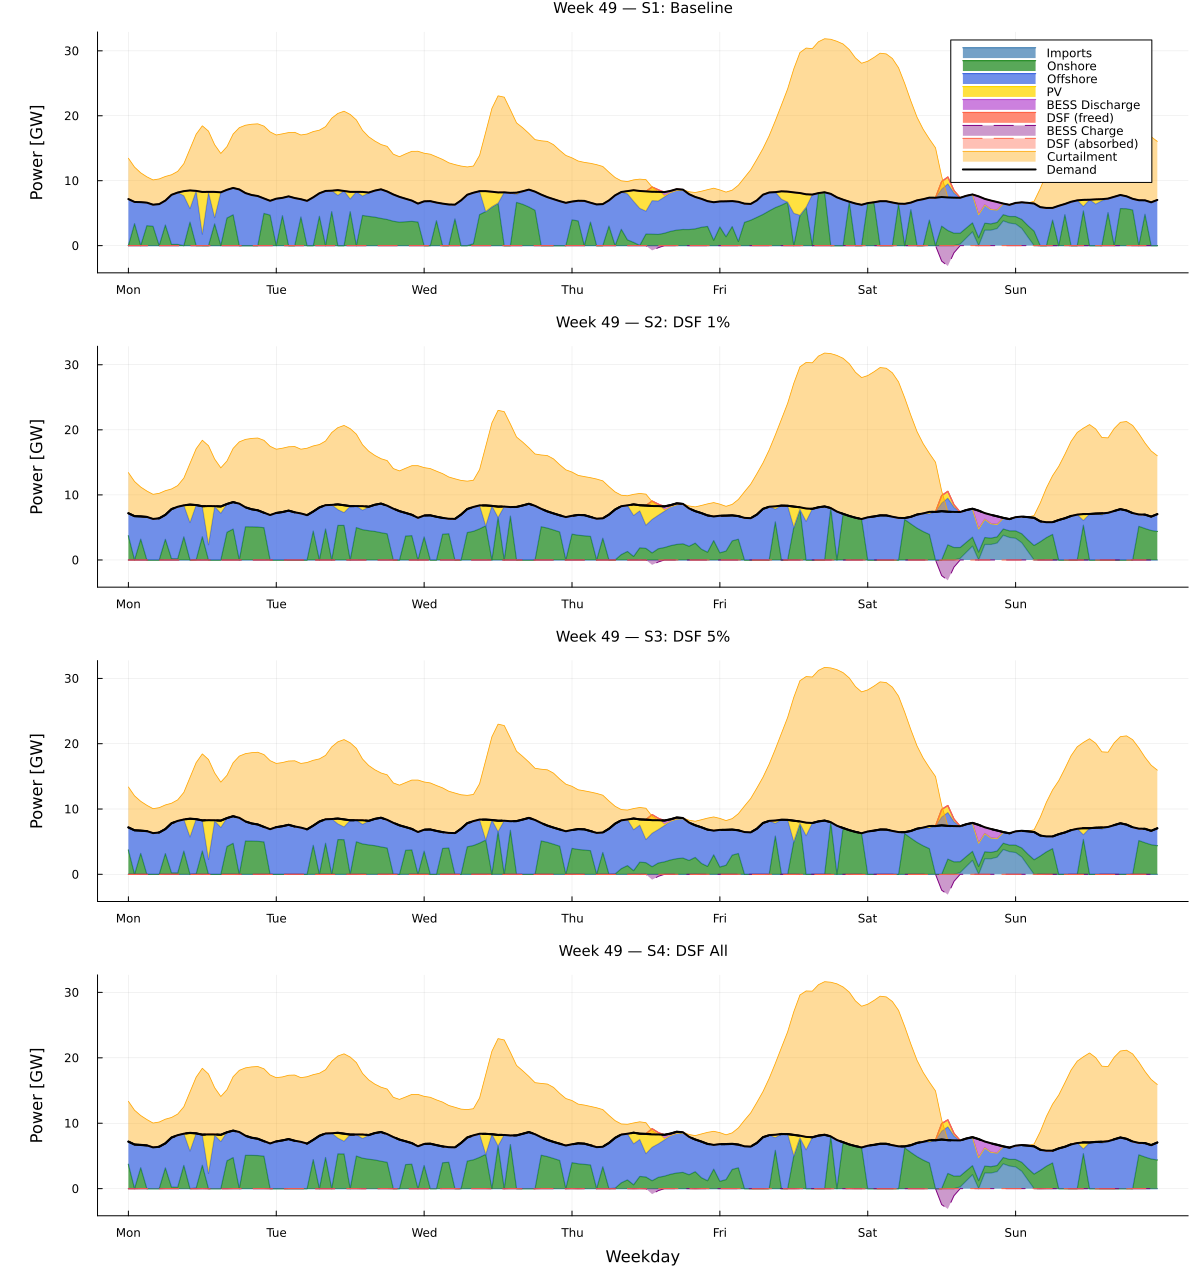

In [20]:

using Dates

df_time = DataFrame(
    t       = collect(H),
    TimeDK  = consumption_wide.TimeDK,
    Date    = consumption_wide.Date,
    Week    = week.(consumption_wide.Date),
    Weekday = dayname.(consumption_wide.Date),
    Hour    = hour.(DateTime.(consumption_wide.TimeDK, "yyyy-mm-ddTHH:MM:SS"))
)



using DataFrames, Plots, JuMP, Dates

# ── One representative week per scenario, with BESS and DSF dynamics ──────
models      = [m1,             m2,           m3,           m4           ]
model_names = ["S1: Baseline", "S2: DSF 1%", "S3: DSF 5%", "S4: DSF All"]
techs_res   = ["onshore", "offshore", "pv"]
week_plot   = 49

wd_levels = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
wd_idx    = Dict(wd_levels .=> collect(1:7))

nrows = length(models)

plt = plot(layout      = (nrows, 1),
           size        = (1200, 320 * nrows),
           ylabel      = "Power [GW]",
           left_margin = 10Plots.mm)

# Select week hours
gd        = filter(:Week => ==(week_plot), df_time)
sort!(gd, :t)
xd        = [wd_idx[String(d)] + h/24 for (d,h) in zip(gd.Weekday, gd.Hour)]
pd        = sortperm(xd)
xd        = xd[pd]
hours_idx = gd.t[pd]
n_hours   = length(hours_idx)
yd        = [demand_dict[h] / 1000.0 for h in hours_idx]

for (i, (m, mname)) in enumerate(zip(models, model_names))

    # RES used
    y_res = hcat([
        [max(value(m[:feed_in][p,h]) - value(m[:CU][p,h]), 0.0) / 1000.0
         for h in hours_idx]
        for p in techs_res]...)

    # Curtailment
    y_curt = [sum(value(m[:CU][p,h]) for p in techs_res) / 1000.0
              for h in hours_idx]

    # Imports
    y_imp = [sum(value(m[:I][c,h]) for c in C) / 1000.0
             for h in hours_idx]

    # BESS
    y_dis = [ value(m[:discharge][h]) / 1000.0 for h in hours_idx]
    y_chg = [-value(m[:charge][h])    / 1000.0 for h in hours_idx]

    # DSF — shift_down frees up demand (acts as supply),
    #        shift_up absorbs deferred load (acts as negative supply)
    if m != m1
        y_dsf_pos = [ value(m[:shift_down][h]) / 1000.0 for h in hours_idx]  # supply freed
        y_dsf_neg = [-value(m[:shift_up][h])   / 1000.0 for h in hours_idx]  # load absorbed
    else
        y_dsf_pos = zeros(n_hours)
        y_dsf_neg = zeros(n_hours)
    end

    # ── Supply stack (positive): Imports | Onshore | Offshore | PV | BESS dis | DSF freed
    supply_mat    = hcat(y_imp, y_res, y_dis, y_dsf_pos)
    supply_labels = ["Imports", "Onshore", "Offshore", "PV", "BESS Discharge", "DSF (freed)"]
    supply_colors = [:steelblue, :forestgreen, :royalblue, :gold, :mediumorchid, :tomato]

    cum  = cumsum(supply_mat, dims=2)
    prev = zeros(n_hours)

    for (j, (lab, col_)) in enumerate(zip(supply_labels, supply_colors))
        plot!(plt[i],
              xd, cum[:,j],
              fillrange = prev,
              lw        = 1.2,
              color     = col_,
              fillalpha = 0.75,
              label     = (i == 1 ? lab : ""))
        prev = cum[:,j]
    end

    # ── Negative supply: BESS charge | DSF absorbed
    for (y_neg, col_, lab) in [
            (y_chg,    :purple,   "BESS Charge"),
            (y_dsf_neg, :tomato,  "DSF (absorbed)")
        ]
        plot!(plt[i],
              xd, y_neg,
              fillrange = zeros(n_hours),
              lw        = 1.0,
              color     = col_,
              fillalpha = 0.4,
              linestyle = :dash,
              label     = (i == 1 ? lab : ""))
    end

    # ── Curtailment band above demand
    plot!(plt[i],
          xd, yd .+ y_curt,
          fillrange = yd,
          lw        = 0.8,
          color     = :orange,
          fillalpha = 0.4,
          label     = (i == 1 ? "Curtailment" : ""))

    # ── Baseline demand
    plot!(plt[i],
          xd, yd,
          lw    = 2.0,
          color = :black,
          label = (i == 1 ? "Demand" : ""))

    # ── DSF-adjusted demand (dashed)
    if m != m1
        y_act = [(demand_hh_dict[h] + demand_pub_dict[h] + demand_ind_dict[h] +
                  value(m[:shift_up][h]) - value(m[:shift_down][h])) / 1000.0
                 for h in hours_idx]
        plot!(plt[i],
              xd, y_act,
              lw        = 2.0,
              color     = :black,
              linestyle = :dash,
              label     = (i == 1 ? "Demand (flex)" : ""))
    end

    plot!(plt[i],
          xticks        = (1:7, ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]),
          title         = "Week $week_plot — $mname",
          legend        = (i == 1 ? :topright : false),
          titlefontsize = 10,
          xlabel        = (i == nrows ? "Weekday" : ""))
end

display(plt)

In [21]:


# ── Scenario summary table ─────────────────────────────────────────────────

models      = [m1,             m2,           m3,           m4           ]
model_names = ["S1: Baseline", "S2: DSF 1%", "S3: DSF 5%", "S4: DSF All"]

function scenario_summary(m, mname)
    # All quantities in GWh unless noted
    feed  = sum(value(m[:feed_in][p,h]) for p in P, h in H) / 1e3
    curt  = sum(value(m[:CU][p,h])      for p in P, h in H) / 1e3
    net   = feed - curt
    imp   = sum(value(m[:I][c,h])       for c in C, h in H) / 1e3
    chr   = sum(value(m[:charge][h])    for h in H) / 1e3
    dis   = sum(value(m[:discharge][h]) for h in H) / 1e3
    tot_d = total_demand / 1e3   # GWh

    k_on  = (K0["onshore"]  + value(m[:K_new]["onshore"]))  / 1000   # GW
    k_off = (K0["offshore"] + value(m[:K_new]["offshore"])) / 1000
    k_pv  = (K0["pv"]       + value(m[:K_new]["pv"]))       / 1000

    obj = objective_value(m) / 1e6   # M DKK/year

    if m != m1
        dsf_down = sum(value(m[:shift_down][h]) for h in H) / 1e3
        dsf_up   = sum(value(m[:shift_up][h])   for h in H) / 1e3
    else
        dsf_down = 0.0
        dsf_up   = 0.0
    end

    return (
        mname,
        round(obj,                 digits=2),
        round(k_on,                digits=2),
        round(k_off,               digits=2),
        round(k_pv,                digits=2),
        round(feed,                digits=1),
        round(curt,                digits=1),
        round(100 * curt / feed,   digits=1),
        round(net,                 digits=1),
        round(imp,                 digits=1),
        round(chr,                 digits=1),
        round(dis,                 digits=1),
        round(100 * net / tot_d,   digits=1),
        round(dsf_down,            digits=2),
        round(dsf_up,              digits=2),
    )
end

rows = [scenario_summary(m, n) for (m, n) in zip(models, model_names)]

df_summary = DataFrame(
    "Scenario"              => [r[1]  for r in rows],
    "Obj (M DKK/yr)"        => [r[2]  for r in rows],
    "Onshore (GW)"          => [r[3]  for r in rows],
    "Offshore (GW)"         => [r[4]  for r in rows],
    "PV (GW)"               => [r[5]  for r in rows],
    "RES feed-in (GWh)"     => [r[6]  for r in rows],
    "Curtailment (GWh)"     => [r[7]  for r in rows],
    "Curtailment (%)"       => [r[8]  for r in rows],
    "RES net (GWh)"         => [r[9]  for r in rows],
    "Imports (GWh)"         => [r[10] for r in rows],
    "BESS charged (GWh)"    => [r[11] for r in rows],
    "BESS discharged (GWh)" => [r[12] for r in rows],
    "RES share (%)"         => [r[13] for r in rows],
    "DSF down (GWh)"        => [r[14] for r in rows],
    "DSF up (GWh)"          => [r[15] for r in rows],
)

println("────────────────────────────────────────────────────────────────")
println(" SCENARIO SUMMARY")
println("────────────────────────────────────────────────────────────────")
show(df_summary, allcols=true)

println("\n\n── Cost savings vs S1 Baseline ─────────────────────────────────")
obj1 = objective_value(m1) / 1e6
for (m, mname) in zip(models[2:end], model_names[2:end])
    obj_m = objective_value(m) / 1e6
    Δ     = obj1 - obj_m
    Δpct  = 100 * Δ / obj1
    println(" ", rpad(mname, 15), " : saves ",
            round(Δ, digits=2), " M DKK/yr  (",
            round(Δpct, digits=3), "%)")
end
println("────────────────────────────────────────────────────────────────")

────────────────────────────────────────────────────────────────
 SCENARIO SUMMARY
────────────────────────────────────────────────────────────────
4×15 DataFrame
 Row │ Scenario      Obj (M DKK/yr)  Onshore (GW)  Offshore (GW)  PV (GW)  RES feed-in (GWh)  Curtailment (GWh)  Curtailment (%)  RES net (GWh)  Imports (GWh)  BESS charged (GWh)  BESS discharged (GWh)  RES share (%)  DSF down (GWh)  DSF up (GWh) 
     │ String        Float64         Float64       Float64        Float64  Float64            Float64            Float64          Float64        Float64        Float64             Float64                Float64        Float64         Float64      
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ S1: Baseline         6473.18          12.0          31.64    41.68     159510.0       

---
# Part 3: Characterising Scarcity and the Value of Flexibility

 Part 3 uses the dual variables (shadow prices) from the DSF capacity constraints to characterise **when** the system values flexibility, **why** it values it, and **how much** it values it. The analysis proceeds in four steps:

1. **Shadow prices** — extract the marginal system value of one additional MWh of shifting capacity in each hour
2. **Scarcity characterisation** — identify when and why scarcity occurs
3. **Flexibility demand curve** — sweep $K^{\text{DSF}}$ to trace the system's willingness to pay for flexibility at different quantities
4. **TOU alignment test** — measure the overlap between model-identified scarcity hours and the Tarifmodel 3.0 peak zone

---
## Step 1: Shadow Prices of the DSF Constraint

For each hour $h$ in which the DSF capacity constraint binds — that is,
$\delta^-_h = K^{\text{DSF}}$ — the LP dual variable $\lambda_h$ is defined as:

$$
\lambda_h = \frac{\partial z^*}{\partial K^{\text{DSF}}} \bigg|_h
$$

where $z^*$ is the optimal objective value. $\lambda_h$ measures the reduction in total annualised system cost (DKK) that would result from relaxing the DSF cap by one MWh in hour $h$. It is a local, marginal measure — valid at the current $K^{\text{DSF}}$.

When $\lambda_h > 0$, the model has exhausted all cheaper options — curtailment reduction, BESS discharge, and cheaper imports — and the shadow price approximately equals the marginal import cost avoided by shifting one MWh of industrial demand away from that hour.

In [22]:
# ── Shadow price extraction ──────────────────────────────────────────────

models_dsf      = [m2,           m3,           m4           ]
model_names_dsf = ["S2: DSF 1%", "S3: DSF 5%", "S4: DSF All"]
K_dsf_vals      = [K_dsf, K_dsf_5, K_dsf_all]

println("────────────────────────────────────────────────────────────────")
println(" SHADOW PRICES — Marginal value of DSF capacity                ")
println("────────────────────────────────────────────────────────────────")

for (m, mname, K_val) in zip(models_dsf, model_names_dsf, K_dsf_vals)

    # Duals on upper bound constraints are non-positive in JuMP — negate
    # for economic interpretation. Objective is in DKK, so duals are DKK/MWh.
    duals_dkk = [-dual(m[:shift_down_cap][h]) for h in H]

    binding    = duals_dkk[duals_dkk .> 1e-4]
    n_bind     = length(binding)

    λ_mean_all  = mean(duals_dkk)
    λ_mean_bind = n_bind > 0 ? mean(binding) : 0.0
    λ_max       = maximum(duals_dkk)
    λ_p95       = quantile(duals_dkk, 0.95)

    println("\n $mname  (K_dsf = $(round(K_val, digits=2)) MWh)")
    println("  Binding hours          : ", n_bind, " / ", length(H),
            "  (", round(100*n_bind/length(H), digits=1), "%)")
    println("  Shadow price (all hrs) : ", round(λ_mean_all,  digits=2), " DKK/MWh")
    println("  Shadow price (binding) : ", round(λ_mean_bind, digits=2), " DKK/MWh")
    println("  Max shadow price       : ", round(λ_max,       digits=2), " DKK/MWh")
    println("  95th pct               : ", round(λ_p95,       digits=2), " DKK/MWh")
end
println("\n────────────────────────────────────────────────────────────────")

────────────────────────────────────────────────────────────────
 SHADOW PRICES — Marginal value of DSF capacity                
────────────────────────────────────────────────────────────────

 S2: DSF 1%  (K_dsf = 13.47 MWh)
  Binding hours          : 902 / 8759  (10.3%)
  Shadow price (all hrs) : 126.19 DKK/MWh
  Shadow price (binding) : 1225.36 DKK/MWh
  Max shadow price       : 2548.95 DKK/MWh
  95th pct               : 1439.76 DKK/MWh

 S3: DSF 5%  (K_dsf = 20.77 MWh)
  Binding hours          : 900 / 8759  (10.3%)
  Shadow price (all hrs) : 122.17 DKK/MWh
  Shadow price (binding) : 1188.97 DKK/MWh
  Max shadow price       : 2547.62 DKK/MWh
  95th pct               : 1426.38 DKK/MWh

 S4: DSF All  (K_dsf = 31.02 MWh)
  Binding hours          : 891 / 8759  (10.2%)
  Shadow price (all hrs) : 121.82 DKK/MWh
  Shadow price (binding) : 1197.54 DKK/MWh
  Max shadow price       : 2547.11 DKK/MWh
  95th pct               : 1423.53 DKK/MWh

────────────────────────────────────────────────

---
## Step 2: Characterising Scarcity Hours

The binding hours identified above are the hours in which the system faces a supply-demand gap that DSF could help close but is prevented by the capacity envelope. This section characterises these hours by season, time of day, and the underlying driver — demand level versus RES availability.

In [23]:
df_time = DataFrame(
    h    = collect(H),
    Date = DateTime.(consumption_wide.TimeDK[collect(H)], "yyyy-mm-ddTHH:MM:SS")
)
df_time[!, :Hour]  = hour.(df_time.Date)
df_time[!, :Month] = month.(df_time.Date)
df_time[!, :Year]  = year.(df_time.Date)

8759-element Vector{Int64}:
 2025
 2025
 2025
 2025
 2025
 2025
 2025
 2025
 2025
 2025
 2025
 2025
 2025
    ⋮
 2025
 2025
 2025
 2025
 2025
 2025
 2025
 2025
 2025
 2025
 2025
 2025

In [24]:
# ── Scarcity hour characteristics ────────────────────────────────────────
using Statistics

duals_all   = [-dual(m2[:shift_down_cap][h]) for h in H]
binding_idx = findall(duals_all .> 1e-4)
non_binding = setdiff(collect(H), binding_idx)

df_scarcity = df_time[binding_idx, :]

# Season mapping
month_to_season = Dict(
    1=>"Winter", 2=>"Winter", 3=>"Spring", 4=>"Spring",
    5=>"Spring", 6=>"Summer", 7=>"Summer", 8=>"Summer",
    9=>"Autumn", 10=>"Autumn", 11=>"Winter", 12=>"Winter"
)
df_scarcity[!, :season] = [month_to_season[month(d)] for d in df_scarcity.Date]

println("── Scarcity hour characteristics ────────────────────────────────")
println(" Total binding hours : ", length(binding_idx), " (",
        round(100*length(binding_idx)/length(H), digits=1), "%)")
println()

println(" By season:")
for s in ["Winter", "Spring", "Summer", "Autumn"]
    n = sum(df_scarcity.season .== s)
    println("  ", rpad(s, 8), " : ", n, " hours  (",
            round(100*n/length(binding_idx), digits=1), "%)")
end

println()
println(" By hour of day (top 6):")
hour_counts = combine(groupby(df_scarcity, :Hour), nrow => :count)
sort!(hour_counts, :count, rev=true)
show(first(hour_counts, 6))
println()

── Scarcity hour characteristics ────────────────────────────────
 Total binding hours : 902 (10.3%)

 By season:
  Winter   : 412 hours  (45.7%)
  Spring   : 180 hours  (20.0%)
  Summer   : 168 hours  (18.6%)
  Autumn   : 142 hours  (15.7%)

 By hour of day (top 6):
6×2 DataFrame
 Row │ Hour   count 
     │ Int64  Int64 
─────┼──────────────
   1 │    19     69
   2 │    20     67
   3 │    21     61
   4 │    18     60
   5 │    22     58
   6 │     0     56


In [25]:
# ── What drives scarcity: demand level or RES availability? ───────────────

res_binding     = [sum(value(m1[:feed_in][p,h]) for p in P) / 1000.0 for h in binding_idx]
res_non_binding = [sum(value(m1[:feed_in][p,h]) for p in P) / 1000.0 for h in non_binding]

dem_binding     = [demand_dict[h] / 1000.0 for h in binding_idx]
dem_non_binding = [demand_dict[h] / 1000.0 for h in non_binding]

println("── What drives scarcity? ───────────────────────────────────────")
println()
println(" RES generation (GW):")
println("  Scarcity hours     — mean: ", round(mean(res_binding),     digits=2),
        "  median: ", round(median(res_binding), digits=2))
println("  Non-scarcity hours — mean: ", round(mean(res_non_binding), digits=2),
        "  median: ", round(median(res_non_binding), digits=2))
println("  Ratio (non-scarcity / scarcity): ",
        round(mean(res_non_binding) / mean(res_binding), digits=1), "×")
println()
println(" Demand (GW):")
println("  Scarcity hours     — mean: ", round(mean(dem_binding),     digits=2),
        "  median: ", round(median(dem_binding), digits=2))
println("  Non-scarcity hours — mean: ", round(mean(dem_non_binding), digits=2),
        "  median: ", round(median(dem_non_binding), digits=2))
println("  Ratio (scarcity / non-scarcity): ",
        round(mean(dem_binding) / mean(dem_non_binding), digits=2), "×")
println()
println(" Finding: scarcity is driven by low RES generation (",
        round(mean(res_non_binding) / mean(res_binding), digits=1),
        "× gap), not elevated demand (ratio ",
        round(mean(dem_binding) / mean(dem_non_binding), digits=2), "×).")

── What drives scarcity? ───────────────────────────────────────

 RES generation (GW):
  Scarcity hours     — mean: 3.41  median: 3.35
  Non-scarcity hours — mean: 19.91  median: 18.32
  Ratio (non-scarcity / scarcity): 5.8×

 Demand (GW):
  Scarcity hours     — mean: 6.39  median: 6.4
  Non-scarcity hours — mean: 6.45  median: 6.56
  Ratio (scarcity / non-scarcity): 0.99×

 Finding: scarcity is driven by low RES generation (5.8× gap), not elevated demand (ratio 0.99×).


---
## Step 3: TOU Alignment Test

Tarifmodel 3.0 defines a peak zone from 17:00–21:00. If the current tariff framework is well-aligned with system needs, the majority of scarcity hours should fall inside this zone. This step tests that assumption directly against the model-identified scarcity hours.

In [26]:
# ── Scarcity hours vs Tarifmodel 3.0 — all three zones ───────────────────

binding_set = Set(binding_idx)

# Tarifmodel 3.0 zones (C-customer, hours 0-23)
tou_lavlast  = Set(0:5)              # 00:00–06:00
tou_hoejlast = Set(vcat(6:16, 21:23)) # 06:00–17:00 and 21:00–24:00
tou_spids    = Set(17:20)             # 17:00–21:00

zones = [
    ("Lavlast (00–06)",      tou_lavlast),
    ("Højlast (06–17, 21–24)", tou_hoejlast),
    ("Spidslast (17–21)",    tou_spids),
]

println("── Scarcity hours vs Tarifmodel 3.0 zones ─────────────────────")
println(" Total scarcity hours : ", length(binding_idx))
println()

println(" A) Where do scarcity hours fall?")
for (name, zone) in zones
    n = sum(df_time.Hour[h] in zone for h in binding_idx)
    println("   ", rpad(name, 28), " : ", rpad(n, 5), " (",
            round(100*n/length(binding_idx), digits=1), "%)")
end

println()
println(" B) What fraction of each zone is actually scarce?")
for (name, zone) in zones
    zone_hours   = [h for h in H if df_time.Hour[h] in zone]
    zone_scarce  = sum(h in binding_set for h in zone_hours)
    println("   ", rpad(name, 28), " : ", rpad(zone_scarce, 5), " / ",
            rpad(length(zone_hours), 5), "  (",
            round(100*zone_scarce/length(zone_hours), digits=1), "% scarce)")
end

println()
println(" C) Shadow price by zone (DKK/MWh, binding hours only):")
for (name, zone) in zones
    zone_binding = [h for h in binding_idx if df_time.Hour[h] in zone]
    if length(zone_binding) > 0
        λ_zone = [-dual(m2[:shift_down_cap][h]) for h in zone_binding]
        println("   ", rpad(name, 28), " : mean ", round(mean(λ_zone), digits=0),
                "  max ", round(maximum(λ_zone), digits=0),
                "  (n=", length(zone_binding), ")")
    else
        println("   ", rpad(name, 28), " : no binding hours")
    end
end

println()
println("── Key finding ─────────────────────────────────────────────────")
lavlast_scarce  = sum(df_time.Hour[h] in tou_lavlast  for h in binding_idx)
hoejlast_scarce = sum(df_time.Hour[h] in tou_hoejlast for h in binding_idx)
spids_scarce    = sum(df_time.Hour[h] in tou_spids     for h in binding_idx)
outside_spids   = length(binding_idx) - spids_scarce

println(" ", round(100*outside_spids/length(binding_idx), digits=0),
        "% of scarcity occurs outside the Spidslast zone")
println(" Tarifmodel 3.0 Lavlast (lowest price) contains ",
        lavlast_scarce, " scarcity hours (",
        round(100*lavlast_scarce/length(binding_idx), digits=1), "%)")
println(" These are hours where the tariff sends the WRONG signal:")
println(" low price encourages consumption, but the system needs demand reduction")

── Scarcity hours vs Tarifmodel 3.0 zones ─────────────────────
 Total scarcity hours : 902

 A) Where do scarcity hours fall?
   Lavlast (00–06)              : 272   (30.2%)
   Højlast (06–17, 21–24)       : 389   (43.1%)
   Spidslast (17–21)            : 241   (26.7%)

 B) What fraction of each zone is actually scarce?
   Lavlast (00–06)              : 272   / 2189   (12.4% scarce)
   Højlast (06–17, 21–24)       : 389   / 5110   (7.6% scarce)
   Spidslast (17–21)            : 241   / 1460   (16.5% scarce)

 C) Shadow price by zone (DKK/MWh, binding hours only):
   Lavlast (00–06)              : mean 1431.0  max 2169.0  (n=272)
   Højlast (06–17, 21–24)       : mean 1076.0  max 2549.0  (n=389)
   Spidslast (17–21)            : mean 1235.0  max 2549.0  (n=241)

── Key finding ─────────────────────────────────────────────────
 73.0% of scarcity occurs outside the Spidslast zone
 Tarifmodel 3.0 Lavlast (lowest price) contains 272 scarcity hours (30.2%)
 These are hours where the tariff 